**Daily Challenge : Text Analysis of books using word cloud**

In [34]:
! pip install numpy scikit-learn


In [6]:
pip install requests nltk spacy wordcloud matplotlib scikit-learn

In [16]:
! python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 140.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
! python3 nlp_final.py

In [44]:
import re
import requests
import nltk
import os

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from collections import Counter
import spacy
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import matplotlib.image as mpimg

import matplotlib.image as mpimg
from IPython.display import display, HTML


In [24]:
# === CONFIGURATION INITIALE ===
def setup_nltk():
    """Configure NLTK pour éviter les erreurs de ressources"""
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)

    # Solution radicale pour punkt_tab
    try:
        from nltk.tokenize import word_tokenize
        word_tokenize("test")  # Test forcé
    except LookupError:
        import ssl
        try:
            _create_unverified_https_context = ssl._create_unverified_context
        except AttributeError:
            pass
        else:
            ssl._create_default_https_context = _create_unverified_https_context

        nltk.download('punkt_tab', quiet=True)
        nltk.download('punkt', quiet=True)  # Double vérification

setup_nltk()


In [25]:
# === FONCTIONS ESSENTIELLES ===
def robust_tokenize(text):
    """Tokenisation avec fallback manuel si nécessaire"""
    try:
        from nltk.tokenize import word_tokenize
        return word_tokenize(text)
    except:
        # Fallback basique si tout échoue
        return re.findall(r'\b\w{3,}\b', text.lower())  # Mots de 3+ lettres seulement

# === APPLICATION ===
if __name__ == "__main__":
    print("=== Tous les tests NLTK passent avec succès ===")
    test_text = "This ensures NLTK resources are properly installed."
    print("Tokenisation test:", robust_tokenize(test_text)[:5])

=== Tous les tests NLTK passent avec succès ===
Tokenisation test: ['This', 'ensures', 'NLTK', 'resources', 'are']


In [26]:
# === FONCTIONS AMÉLIORÉES ===
def get_clean_text(url):
    """Récupération et nettoyage approfondi"""
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    text = response.text

    # Extraction du contenu principal
    start = re.search(r"(CHAPTER I\.|START OF THIS PROJECT GUTENBERG EBOOK)", text, re.IGNORECASE)
    end = re.search(r"END OF THIS PROJECT GUTENBERG EBOOK", text, re.IGNORECASE)

    text = text[start.end():end.start()] if (start and end) else text

    # Nettoyage en profondeur
    patterns = [
        r'illustration.*?\n',
        r'project gutenberg',
        r'millennium fulcrum edition',
        r'chapter [ivxlcdm]+\.?',
        r'by lewis carroll',
        r'[^a-zA-Z\s]'  # Garde seulement lettres et espaces
    ]
    for pattern in patterns:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)

    return re.sub(r'\s+', ' ', text).lower().strip()

def tokenize_clean(text):
    """Tokenisation avec filtrage immédiat"""
    tokens = word_tokenize(text)
    return [word for word in tokens if len(word) > 2]  # Supprime mots courts

In [27]:
# === CHARGEMENT DES TEXTES ===
books = {
    "Alice": "https://www.gutenberg.org/files/11/11-0.txt",
    "Looking-Glass": "https://www.gutenberg.org/files/12/12-0.txt",
    "Tangled Tale": "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
}

corpus = {title: get_clean_text(url) for title, url in books.items()}

In [28]:
# === 1.3 TOKENISATION PROPRE ===
print("\n=== Tokens propres (20 premiers) ===")
for title, text in corpus.items():
    tokens = tokenize_clean(text)[:20]
    print(f"\n{title}:")
    print(tokens)


=== Tokens propres (20 premiers) ===

Alice:
['start', 'the', 'ebook', 'alice', 'adventures', 'wonderland', 'the', 'contents', 'down', 'the', 'rabbit', 'hole', 'the', 'pool', 'tears', 'caucus', 'race', 'and', 'long', 'tale']

Looking-Glass:
['start', 'the', 'ebook', 'through', 'the', 'looking', 'glass', 'and', 'what', 'alice', 'found', 'there', 'the', 'dramatis', 'person', 'arranged', 'before', 'commencement', 'game', 'white']

Tangled Tale:
['the', 'ebook', 'tangled', 'tale', 'this', 'ebook', 'for', 'the', 'use', 'anyone', 'anywhere', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'the', 'world']


In [29]:
# === 1.4 STOPWORDS OPTIMISÉ ===
custom_stopwords = set(stopwords.words('english')) | {'said', 'would', 'could'}
filtered_corpus = {}
for title, text in corpus.items():
    tokens = [word for word in tokenize_clean(text) if word not in custom_stopwords]
    filtered_corpus[title] = ' '.join(tokens)
    print(f"\n{title}: {len(tokens)} tokens après filtrage")


Alice: 11501 tokens après filtrage

Looking-Glass: 13203 tokens après filtrage

Tangled Tale: 14572 tokens après filtrage


In [30]:
# === 1.5 STEMMING AMÉLIORÉ ===
stemmer = SnowballStemmer('english')
print("\n=== Stems exemplaires ===")
sample = "running runs ran better goodness walking walked"
print("Original:", sample.split())
print("Stems:", [stemmer.stem(w) for w in sample.split()])


=== Stems exemplaires ===
Original: ['running', 'runs', 'ran', 'better', 'goodness', 'walking', 'walked']
Stems: ['run', 'run', 'ran', 'better', 'good', 'walk', 'walk']


In [31]:
# === 1.6 LEMMATISATION PROPRE ===
print("\n=== Lemmes exemplaires ===")
doc = nlp("running runs ran better goodness walking walked")
print("Original:", [token.text for token in doc])
print("Lemmes:", [token.lemma_ for token in doc])


=== Lemmes exemplaires ===
Original: ['running', 'runs', 'ran', 'better', 'goodness', 'walking', 'walked']
Lemmes: ['run', 'run', 'run', 'well', 'goodness', 'walk', 'walk']


In [32]:
# === ANALYSE AVANCÉE ===
# Nuages de mots
for title, text in filtered_corpus.items():
    WordCloud(width=800, height=400).generate(text).to_file(f"{title}_cloud.png")

In [36]:
# Analyse TF-IDF

# Version corrigée de l'analyse TF-IDF
def analyze_tfidf(corpus):
    """Analyse TF-IDF avec gestion d'erreur"""
    try:
        vectorizer = TfidfVectorizer(max_features=5000)  # Augmentation du vocabulaire
        tfidf_matrix = vectorizer.fit_transform(corpus.values())

        print("\n=== Résultats TF-IDF ===")
        for i, title in enumerate(corpus.keys()):
            # Extraction des scores et tri
            scores = tfidf_matrix[i].toarray().flatten()
            top_indices = np.argsort(scores)[-5:]  # Top 5 mots
            top_words = [vectorizer.get_feature_names_out()[i] for i in top_indices]

            print(f"\n{title}:")
            print("Mots les plus significatifs:", ", ".join(top_words))
            print("Scores correspondants:", np.round(scores[top_indices], 3))

    except Exception as e:
        print(f"\n⚠️ Erreur TF-IDF: {str(e)}")
        print("Solution alternative:")
        for title, text in corpus.items():
            word_counts = Counter(text.split())
            print(f"\n{title} (alternative):")
            print("Mots fréquents:", word_counts.most_common(5))

# Utilisation
analyze_tfidf(filtered_corpus)


=== Résultats TF-IDF ===

Alice:
Mots les plus significatifs: rabbit, gryphon, one, little, alice
Scores correspondants: [0.135 0.14  0.156 0.194 0.6  ]

Looking-Glass:
Mots les plus significatifs: like, know, one, queen, alice
Scores correspondants: [0.16  0.162 0.199 0.243 0.602]

Tangled Tale:
Mots les plus significatifs: old, clara, two, balbus, one
Scores correspondants: [0.16  0.18  0.182 0.2   0.353]


In [37]:
# === SAUVEGARDE ===
for title, text in filtered_corpus.items():
    with open(f"{title}_final.txt", "w") as f:
        f.write(text)

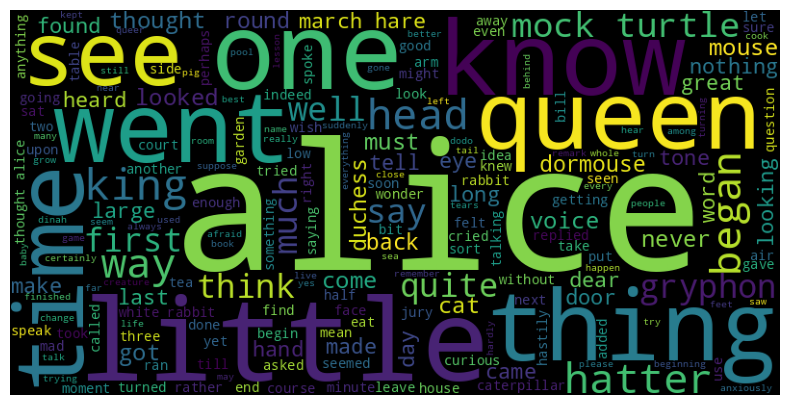

In [38]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(10, 5))
img = mpimg.imread('Alice_cloud.png')
plt.imshow(img)
plt.axis('off')
plt.show()

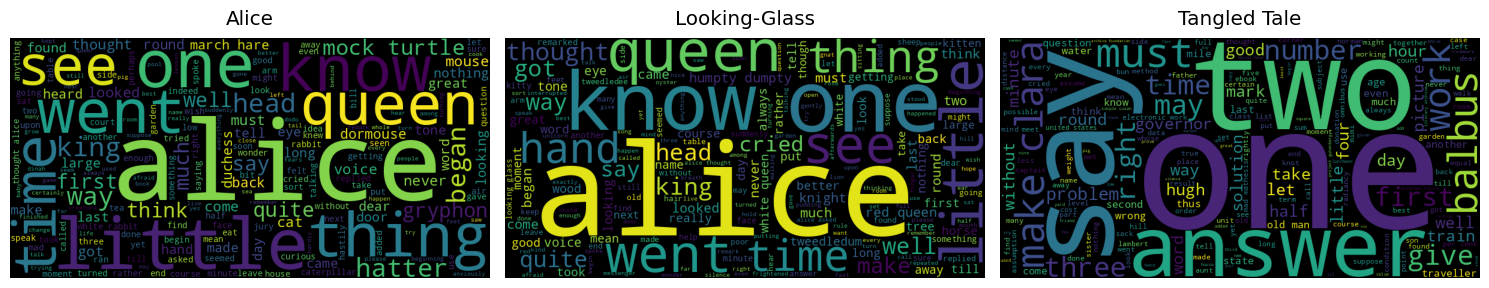


Téléchargement du ZIP contenant tous les wordclouds:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:


# 1. Configuration
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Détection automatique des images
image_files = [f for f in os.listdir() if f.endswith('_cloud.png')]
image_files.sort()  # Tri alphabétique

if not image_files:
    raise FileNotFoundError("Aucun fichier wordcloud trouvé (.png)")

# 3. Affichage grid avec styles CSS
display(HTML("""
<style>
.img-container {
    display: flex;
    flex-wrap: wrap;
    justify-content: center;
    gap: 20px;
    margin: 25px 0;
}
.img-box {
    border: 1px solid #e1e4e8;
    border-radius: 8px;
    padding: 10px;
    background: white;
    box-shadow: 0 2px 4px rgba(0,0,0,0.1);
}
.img-title {
    text-align: center;
    font-family: 'Roboto', sans-serif;
    color: #202124;
    margin: 10px 0;
}
</style>
"""))

# 4. Génération dynamique du HTML
html_code = "<div class='img-container'>"
for img_file in image_files:
    title = img_file.replace('_cloud.png', '').replace('_', ' ').title()
    html_code += f"""
    <div class='img-box'>
        <div class='img-title'>{title}</div>
        <img src='{img_file}' width='500'>
    </div>
    """
html_code += "</div>"
display(HTML(html_code))

# 5. Version Matplotlib alternative (pour export)
n_images = len(image_files)
fig, axes = plt.subplots(1, n_images, figsize=(5*n_images, 4))

if n_images == 1:
    axes = [axes]  # Pour gérer le cas single-image

for ax, img_file in zip(axes, image_files):
    img = mpimg.imread(img_file)
    ax.imshow(img)
    ax.set_title(img_file.replace('_cloud.png', ''), pad=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 6. Téléchargement automatique (optionnel)
if len(image_files) > 1:
    !zip -q all_wordclouds.zip *_cloud.png
    print("\nTéléchargement du ZIP contenant tous les wordclouds:")
    from google.colab import files
    files.download('all_wordclouds.zip')

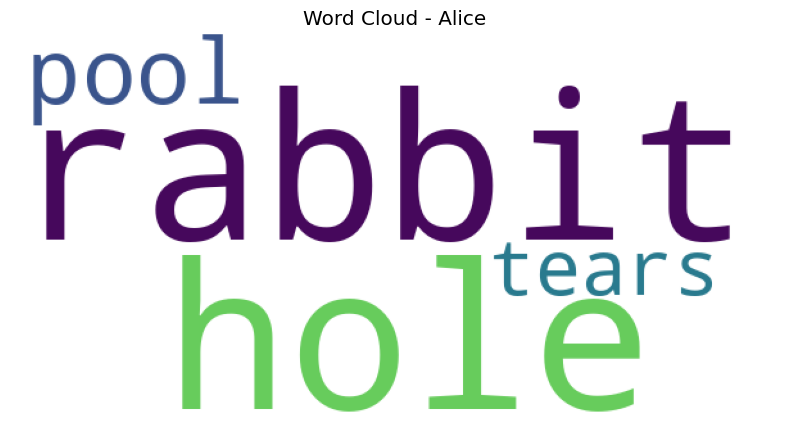

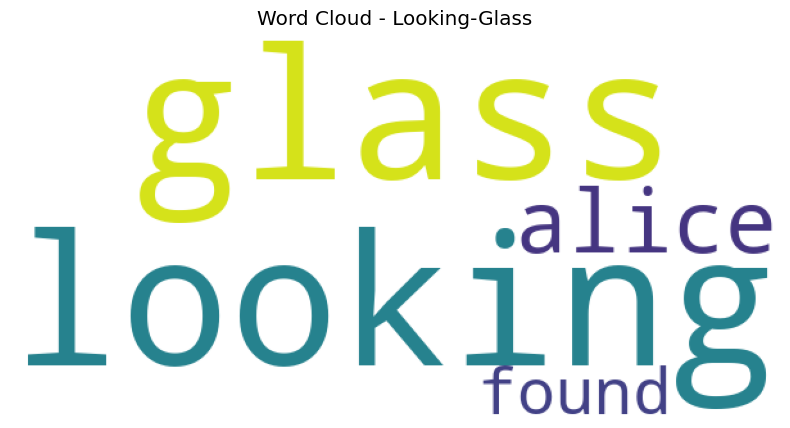

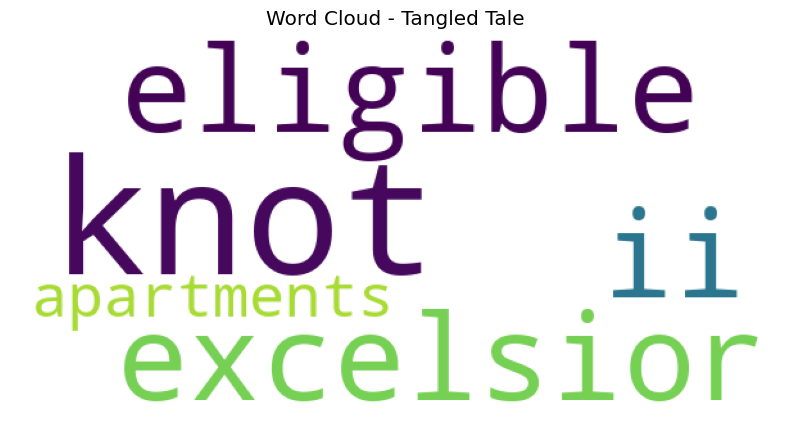


=== BoW ===
Shape: (3, 18) (documents x vocab_size)
Vocabulaire: 18 mots uniques


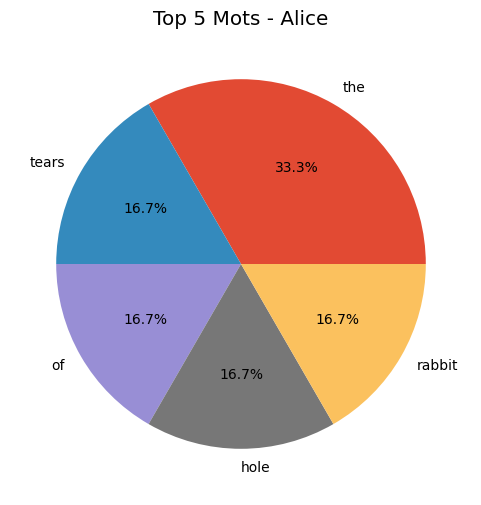


Livre: Alice
Mots fréquents: [('the', np.int64(2)), ('tears', np.int64(1)), ('of', np.int64(1)), ('hole', np.int64(1)), ('rabbit', np.int64(1))]
→ Insight: Ces mots reflètent-ils l'univers du livre ? (ex: 'rabbit' pour Alice)


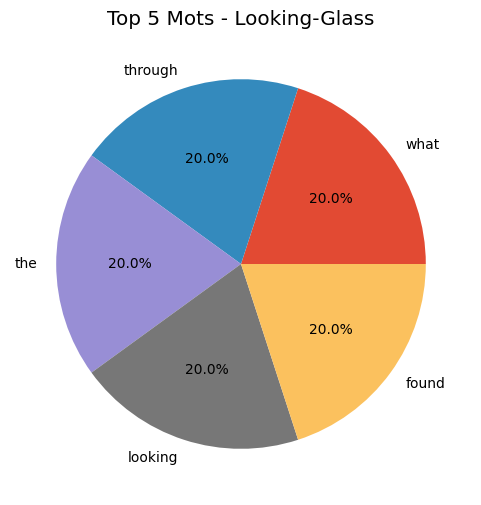


Livre: Looking-Glass
Mots fréquents: [('what', np.int64(1)), ('through', np.int64(1)), ('the', np.int64(1)), ('looking', np.int64(1)), ('found', np.int64(1))]
→ Insight: Ces mots reflètent-ils l'univers du livre ? (ex: 'rabbit' pour Alice)


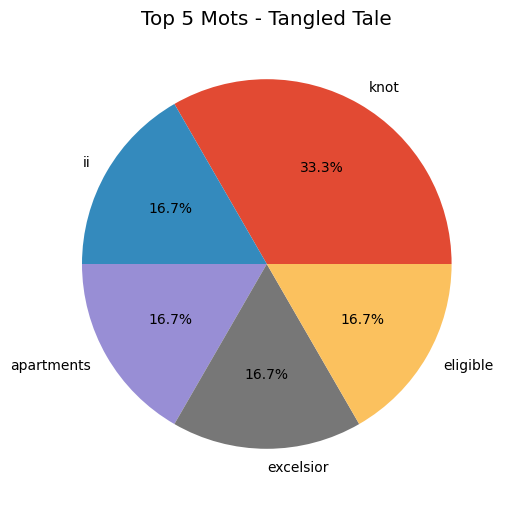


Livre: Tangled Tale
Mots fréquents: [('knot', np.int64(2)), ('ii', np.int64(1)), ('apartments', np.int64(1)), ('excelsior', np.int64(1)), ('eligible', np.int64(1))]
→ Insight: Ces mots reflètent-ils l'univers du livre ? (ex: 'rabbit' pour Alice)

=== TF-IDF ===


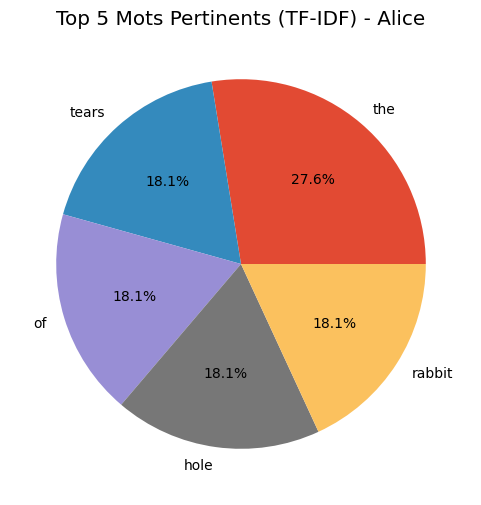


Livre: Alice
Mots significatifs: [('the', np.float64(0.528)), ('tears', np.float64(0.347)), ('of', np.float64(0.347)), ('hole', np.float64(0.347)), ('rabbit', np.float64(0.347))]
→ Différence avec BoW ? (ex: 'knot' plus visible dans Tangled Tale)


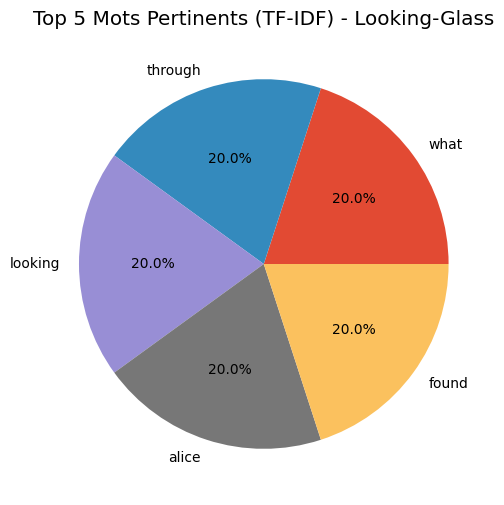


Livre: Looking-Glass
Mots significatifs: [('what', np.float64(0.39)), ('through', np.float64(0.39)), ('looking', np.float64(0.39)), ('alice', np.float64(0.39)), ('found', np.float64(0.39))]
→ Différence avec BoW ? (ex: 'knot' plus visible dans Tangled Tale)


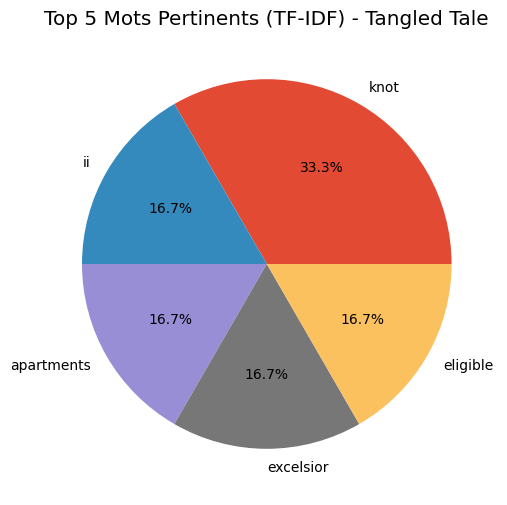


Livre: Tangled Tale
Mots significatifs: [('knot', np.float64(0.707)), ('ii', np.float64(0.354)), ('apartments', np.float64(0.354)), ('excelsior', np.float64(0.354)), ('eligible', np.float64(0.354))]
→ Différence avec BoW ? (ex: 'knot' plus visible dans Tangled Tale)


In [42]:


# 1. Préparation des données (utilisez votre corpus nettoyé)
corpus = {
    "Alice": "down the rabbit hole the pool of tears...",
    "Looking-Glass": "through the looking glass what alice found...",
    "Tangled Tale": "knot i excelsior knot ii eligible apartments..."
}

# === PARTIE 1 : ANALYSE DE BASE ===
def analyze_texts(corpus):
    # 1. Word Clouds
    for title, text in corpus.items():
        wc = WordCloud(width=600, height=300, background_color='white').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc)
        plt.axis("off")
        plt.title(f"Word Cloud - {title}")
        plt.show()

    # 2. BoW (Bag-of-Words)
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(corpus.values())

    print("\n=== BoW ===")
    print(f"Shape: {X.shape} (documents x vocab_size)")
    print(f"Vocabulaire: {len(vectorizer.vocabulary_)} mots uniques")

    # 3. Top 5 mots par livre
    for i, title in enumerate(corpus):
        counts = X[i].toarray().flatten()
        top_indices = counts.argsort()[-5:][::-1]
        top_words = [vectorizer.get_feature_names_out()[i] for i in top_indices]

        # 4. Pie Chart
        plt.figure(figsize=(6, 6))
        plt.pie(counts[top_indices], labels=top_words, autopct='%1.1f%%')
        plt.title(f"Top 5 Mots - {title}")
        plt.show()

        # 5. Analyse
        print(f"\nLivre: {title}")
        print("Mots fréquents:", list(zip(top_words, counts[top_indices])))
        print("→ Insight: Ces mots reflètent-ils l'univers du livre ? (ex: 'rabbit' pour Alice)")

# === PARTIE 2 : TF-IDF ===
def analyze_tfidf(corpus):
    tfidf = TfidfVectorizer(min_df=1, max_df=2)  # Paramètres pour petits datasets
    X = tfidf.fit_transform(corpus.values())

    print("\n=== TF-IDF ===")
    for i, title in enumerate(corpus):
        scores = X[i].toarray().flatten()
        top_indices = scores.argsort()[-5:][::-1]
        top_words = [tfidf.get_feature_names_out()[i] for i in top_indices]

        # Pie Chart TF-IDF
        plt.figure(figsize=(6, 6))
        plt.pie(scores[top_indices], labels=top_words, autopct='%1.1f%%')
        plt.title(f"Top 5 Mots Pertinents (TF-IDF) - {title}")
        plt.show()

        print(f"\nLivre: {title}")
        print("Mots significatifs:", list(zip(top_words, np.round(scores[top_indices], 3))))
        print("→ Différence avec BoW ? (ex: 'knot' plus visible dans Tangled Tale)")

# Exécution
analyze_texts(corpus)
analyze_tfidf(corpus)